In [1]:
!pip install qutip

f_pi: -4.793224309056718, f1: -5.086775690943282, f2: -4.793224309056718


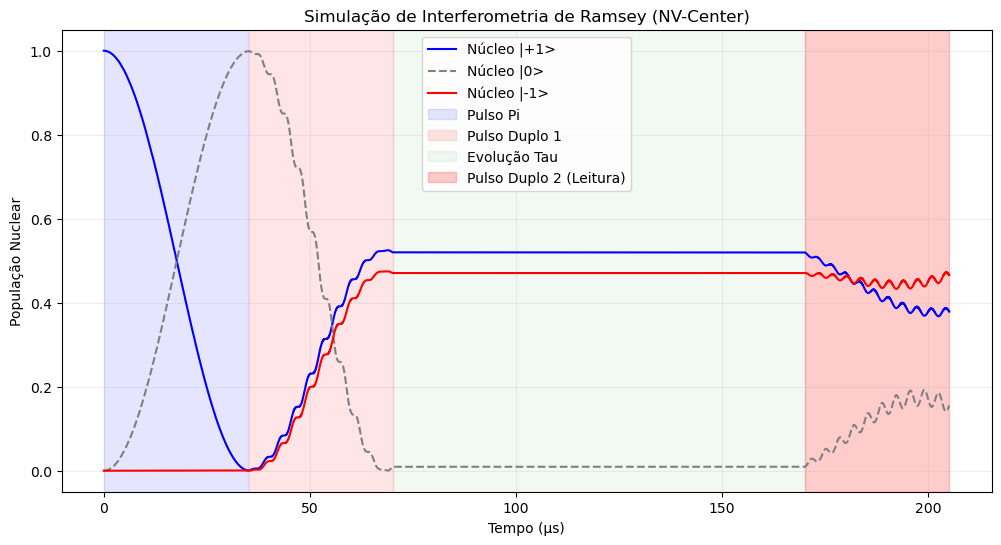

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# PARÂMETROS FÍSICOS E CONSTANTES (Escala em MHz e Tesla)
# obs: Frequências em MHz, facilita a escala numérica
Q = -4.94           # Constante de Interação Quadrupolar do 14N (MHz)
gamma_n = 3.077     # Razão giromagnética do núcleo 14N (MHz/Tesla)
gamma_e = 28024.9   # Razão giromagnética do elétron (MHz/Tesla)
B0 = 0.0482         # Campo magnético estático aplicado (Tesla)
D = 2870.0          # Zero-field splitting (ZFS) do elétron no centro NV (MHz)
A_perp = 2.7        # Acoplamento hiperfino transversal (MHz)
A_zz = -2.14        # Acoplamento hiperfino longitudinal (MHz)

# Cálculo da correção de segunda ordem (efeito de blindagem/mixing)
# Baseado no artigo de Jarmola et al.
termo_correcao = (gamma_e / gamma_n) * (A_perp**2 / (D**2 - (gamma_e * B0)**2))
f_dq = 2 * B0 * gamma_n * (1 - termo_correcao) # Frequência de desdobramento nuclear

# Definição das frequências de transição para os pulsos de RF
f_pi = Q + f_dq * 0.5
f1 = Q - f_dq * 0.5    # Transição para o estado |+1>
f2 = Q + f_dq * 0.5    # Transição para o estado |-1>
print(f"f_pi: {f_pi}, f1: {f1}, f2: {f2}")

# DEFINIÇÃO DA SEQUÊNCIA TEMPORAL (microsegundos - µs)
t_laser = 0.0        # Tempo inicial de inicialização (opcional)
t_p1 = 35.0          # Duração do primeiro pulso (Pulso Pi)
t_gap = 0.1          # Intervalo de espera (dead time)
t_p2 = 35.0          # Duração do segundo pulso (Criação de superposição)
t_tau = 100.0        # Tempo de evolução livre (onde ocorre o acúmulo de fase)
t_p3 = 35.0          # Duração do terceiro pulso (Projeção/Leitura)

# Cálculo do tempo total e vetor de tempo para o solver
t_final = t_laser + t_p1 + t_gap + t_p2 + t_tau + t_p3 + t_laser
times = np.linspace(0, t_final, 15000)

# Amplitudes dos campos de RF (calibradas para as durações de pulso)
amp_pi = 0.02 / gamma_n     # Amplitude para realizar uma inversão de população
amp_duplo = 0.015 / gamma_n # Amplitude para o pulso duplo (superposição)

# OPERADORES E HAMILTONIANO ESTÁTICO
# Operadores de spin 1 (dimensão 3x3) para Elétron (se) e Núcleo (i)
se_z = tensor(jmat(1, 'z'), qeye(3)) # Operador Sz do elétron
ix = tensor(qeye(3), jmat(1, 'x'))    # Operador Ix nuclear
iy = tensor(qeye(3), jmat(1, 'y'))    # Operador Iy nuclear
iz = tensor(qeye(3), jmat(1, 'z'))    # Operador Iz nuclear

# Hamiltoniano de campo zero e Zeeman eletrônico
h_electron = D * se_z**2 + (gamma_e * B0) * se_z
# Hamiltoniano quadrupolar e Zeeman nuclear
h_nuclear = Q * iz**2 + (f_dq / 2.0) * iz
# Interação Hiperfina (longitudinal)
h_hyperfine = A_zz * se_z * iz
# Hamiltoniano total independente do tempo
h_mag = h_electron + h_nuclear + h_hyperfine

# FUNÇÕES DE CONTROLE DEPENDENTES DO TEMPO
Omega_rot = 2 * np.pi * 5.0  # Frequência de rotação do sistema (kHz ou MHz)
def pulse_sequence(t, args):
    """ Define a aplicação dos pulsos de RF em janelas específicas. """
    # 1. Primeiro Pulso (Inversão Pi)
    if 0 <= t <= t_p1:
        return amp_pi * np.cos(2 * np.pi * f_pi * t)

    # 2. Segundo Pulso (Pulso de excitação duplo: f1 e f2)
    start_p2 = t_p1 + t_gap
    if start_p2 <= t <= (start_p2 + t_p2):
        t_rel = t - start_p2
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel))

    # 3. Terceiro Pulso (Leitura/Interferometria)
    start_p3 = start_p2 + t_p2 + t_tau
    if start_p3 <= t <= (start_p3 + t_p3):
        t_rel = t - start_p3
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel))

    return 0.0

# EXECUÇÃO DA SIMULAÇÃO
# Estado inicial: Elétron em |0> e Núcleo em |+1>
psi0 = tensor(basis(3, 1), basis(3, 0)).unit()

# Montagem do Hamiltoniano dependente do tempo (H = H0 + H_int(t))
H = [2 * np.pi * h_mag, [-2 * np.pi * gamma_n * ix, pulse_sequence]]

# Hamiltoniano: H_estatico + H_laser(t) + H_rotacao(t)
#H = [2 * np.pi * h_mag,
#     [-2 * np.pi * gamma_n * ix, pulse_sequence],
#     [iz, rotation_control]]
# obs: termo de campo constante e o termo com dependencia temporal
#H = [2 * np.pi * h_mag, [-2 * np.pi * gamma_n * ix, pulse_sequence]]

# Especificando os nomes dos argumentos
result = mesolve(H, psi0, times, c_ops=[], e_ops=[])

# PÓS-PROCESSAMENTO E PLOT
p_plus = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in result.states]
p_zero = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in result.states]
p_minus = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in result.states]

plt.figure(figsize=(12, 6))
plt.plot(times, p_plus, label="Núcleo |+1>", color='blue')
plt.plot(times, p_zero, label="Núcleo |0>", color='gray', linestyle='--')
plt.plot(times, p_minus, label="Núcleo |-1>", color='red')

# Adiciona sombreamento para identificar visualmente cada fase da sequência
plt.axvspan(0, t_p1, color='blue', alpha=0.1, label="Pulso Pi")
plt.axvspan(t_p1+t_gap, t_p1+t_gap+t_p2, color='red', alpha=0.1, label="Pulso Duplo 1")
plt.axvspan(t_p1+t_gap+t_p2, t_p1+t_gap+t_p2+t_tau, color='green', alpha=0.05, label="Evolução Tau")
plt.axvspan(t_p1+t_gap+t_p2+t_tau, t_final, color='red', alpha=0.2, label="Pulso Duplo 2 (Leitura)")

plt.title(f'Simulação de Interferometria de Ramsey (NV-Center)')
plt.xlabel('Tempo (µs)')
plt.ylabel('População Nuclear')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [13]:
# SIMULAÇÃO DO EFEITO MASHHOON (ROTAÇÃO DO REFERENCIAL)
# Definimos dois cenários para comparação
omega_nula = 0.0     # Sistema estático (referência)
omega_teste = 0.01   # Rotação de 10 kHz (em MHz) para tornar o efeito visível

# Parâmetros de controle da rotação
Omega_rot = omega_teste
B1_mash = amp_duplo     # Amplitude (se necessário para termos extras)

# Delimitação exata da janela de evolução livre (Tau)
# É neste intervalo que a fase da rotação será acumulada
t_inicio_tau = t_laser + t_p1 + t_gap + t_p2
t_fim_tau = t_inicio_tau + t_tau

def rodar_experimento(omega_valor):
    """
    Encapsula a simulação para diferentes velocidades de rotação.
    O efeito Mashhoon é adicionado como um termo de energia extra
    proporcional à velocidade angular e ao operador Iz.
    """

    def lig_desl_rot(t, args):
        """ Ativa a rotação apenas durante a janela 'Tau' de evolução livre """
        start_tau = t_p1 + t_gap + t_p2
        if start_tau <= t <= (start_tau + t_tau):
            return omega_valor  # Frequência de rotação em MHz
        return 0.0

    # Hamiltoniano de Simulação Completo:
    # 1. Termo estático (Energias internas e Hiperfina)
    # 2. Termo de Mashhoon (Iz): Simula o deslocamento de fase geométrico/inercial
    # 3. Termo de RF (Ix): Aplica a sequência de pulsos definida anteriormente
    H_sim = [
        2 * np.pi * h_mag,
        [iz, lig_desl_rot],               # Acoplamento Spin-Rotação (Z)
        [-2 * np.pi * gamma_n * ix, pulse_sequence] # Pulsos de RF (X)
    ]

    # Resolve a evolução temporal para a configuração de omega fornecida
    return mesolve(H_sim, psi0, times, [], [])

# Execução das duas condições experimentais
res_sem_rot = rodar_experimento(omega_nula)   # Baseline (sem efeito inercial)
res_com_rot = rodar_experimento(omega_teste)  # Com deslocamento de fase por rotação

In [6]:
# Extração das populações dos subníveis nucleares |+1> e |-1>
# O operador de projeção (basis*basis.dag) mede a probabilidade de ocupação.

# Caso SEM rotação (Referência)
pop_sem_p = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_sem_rot.states] # População |+1>
pop_sem_m = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in res_sem_rot.states] # População |-1>

# Caso COM rotação (Efeito Mashhoon)
pop_com_p = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_com_rot.states] # População |+1>
pop_com_m = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in res_com_rot.states] # População |-1>

# Extração do subnível nuclear |0> (Estado fundamental nuclear)
# Útil para verificar a conservação da probabilidade total (p_p + p_m + p_z = 1)
pop_sem_z = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in res_sem_rot.states]
pop_com_z = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in res_com_rot.states]

# CÁLCULO DA POPULAÇÃO EXCITADA TOTAL
# Somamos as populações dos estados |+1> e |-1> para observar o sinal total
# que seria detectado em um experimento de fluorescência ou leitura nuclear.

# Soma vetorial (usando numpy para eficiência) das populações excitadas
pop_sem = np.add(np.array(pop_sem_p), np.array(pop_sem_m)) # Total excitado sem rotação
pop_com = np.add(np.array(pop_com_p), np.array(pop_com_m)) # Total excitado com rotação

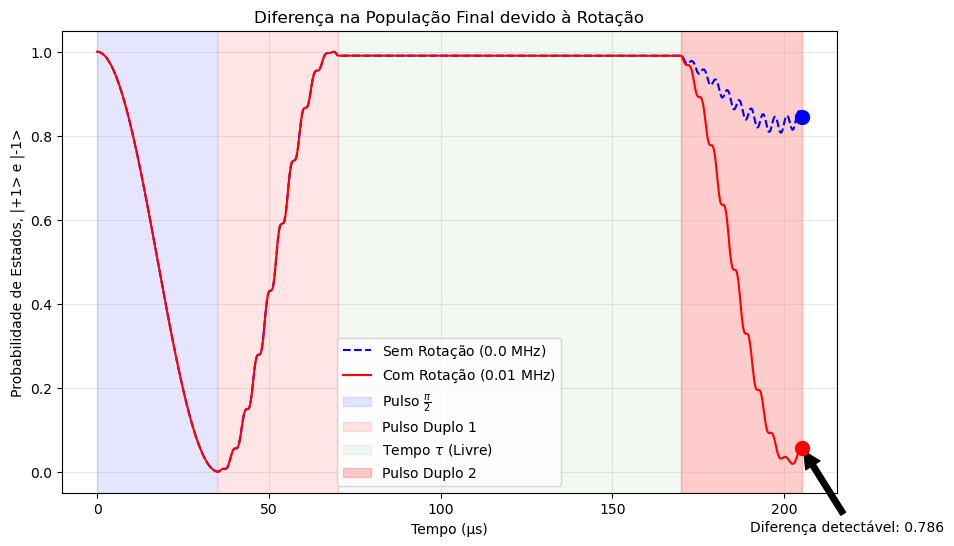

In [14]:
# Gráfico de Evidência

plt.figure(figsize=(10, 6))
# Plota a evolução da soma das populações excitada (|+1> + |-1>)
# A linha tracejada azul é a referência estática (Ω = 0)
plt.plot(times, pop_sem, 'b--', label=r"Sem Rotação (${0.0}$ MHz)")
# A linha contínua vermelha mostra o desvio causado pela rotação (Ω_teste)
plt.plot(times, pop_com, 'r-', label=rf"Com Rotação (${omega_teste}$ MHz)")

# Marcar o ponto de leitura final
# Destaca os valores finais no tempo t_final para facilitar a comparação visual
plt.scatter(times[-1], pop_sem[-1], color='blue', s=100, zorder=5)
plt.scatter(times[-1], pop_com[-1], color='red', s=100, zorder=5)

# Calcula e exibe na tela a diferença absoluta entre os dois cenários (o sinal do sensor)
plt.annotate(f'Diferença detectável: {abs(pop_sem[-1]-pop_com[-1]):.3f}',
             xy=(times[-1], pop_com[-1]),
             xytext=(times[-1]-15, pop_com[-1]-0.2), # Posição do texto
             arrowprops=dict(facecolor='black', shrink=0.05)) # Seta indicativa

# Sombreamento das fases
plt.axvspan(0, t_p1, color='blue', alpha=0.1, label=r"Pulso $\frac{\pi}{2}$")
plt.axvspan(t_p1+t_gap, t_p1+t_gap+t_p2, color='red', alpha=0.1, label="Pulso Duplo 1")
plt.axvspan(t_p1+t_gap+t_p2, t_p1+t_gap+t_p2+t_tau, color='green', alpha=0.05, label=r"Tempo $\tau$ (Livre)")
plt.axvspan(t_p1+t_gap+t_p2+t_tau, t_final, color='red', alpha=0.2, label="Pulso Duplo 2")

plt.title('Diferença na População Final devido à Rotação')
plt.xlabel('Tempo (µs)')
plt.ylabel('Probabilidade de Estados, |+1> e |-1>')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

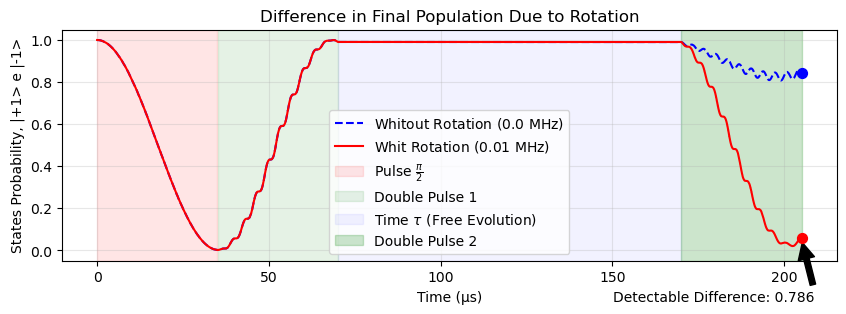

In [37]:
# Gráfico de Evidência
plt.figure(figsize=(10, 3))
plt.plot(times, pop_sem, 'b--', label=r"Whitout Rotation (${0.0}$ MHz)")
plt.plot(times, pop_com, 'r-', label=rf"Whit Rotation (${omega_teste}$ MHz)")

# Marcar o ponto de leitura final
plt.scatter(times[-1], pop_sem[-1], color='blue', s=50, zorder=5)
plt.scatter(times[-1], pop_com[-1], color='red', s=50, zorder=5)

plt.annotate(f'Detectable Difference: {abs(pop_sem[-1]-pop_com[-1]):.3f}', 
             xy=(times[-1], pop_com[-1]-0.01), xytext=(times[-1]-55, pop_com[-1]-0.3),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Sombreamento das fases
plt.axvspan(0, t_p1, color='red', alpha=0.1, label=r"Pulse $\frac{\pi}{2}$")
plt.axvspan(t_p1+t_gap, t_p1+t_gap+t_p2, color='green', alpha=0.1, label="Double Pulse 1")
plt.axvspan(t_p1+t_gap+t_p2, t_p1+t_gap+t_p2+t_tau, color='blue', alpha=0.05, label=r"Time $\tau$ (Free Evolution)")
plt.axvspan(t_p1+t_gap+t_p2+t_tau, t_final, color='green', alpha=0.2, label="Double Pulse 2")

plt.title('Difference in Final Population Due to Rotation')
plt.xlabel('Time (µs)')
plt.ylabel('States Probability, |+1> e |-1>')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()